# 2. Core Gene Selection

**Core gene selection:** ranking is signed, not by absolute value. Rest, Stim48hr, and Stim8hr (standard split) select top 50 (activators) + bottom 150 (suppressors) from `DPD_stim`, 200 genes.

**R (square, core x core):** built directly here from `DE_stats`, not reconstructed later in Notebook 3 this is the only expression matrix this notebook needs.

### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


Condition, paths, and the core gene selection / UMAP parameters for this run. Must match Notebook 1 (`CONDITION`, `DONORS`).

In [2]:
# Must match Notebook 1
CONDITION = 'Stim48hr'  # 'Rest', 'Stim8hr', 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# Paths
DATA_DIR = '../Data'
DESTATS_PATH = '../Data/GWCD4i.DE_stats.h5ad'
IN_DIR = f'../Results/{CONDITION}'  # Notebook 1 outputs
OUT_DIR = f'../Results/{CONDITION}'
os.makedirs(OUT_DIR, exist_ok=True)
# R (square, core x core) goes straight into the pseudobulk subfolder Notebook 3 reads from.
PSEUDOBULK_OUT_DIR = f'../Results/{CONDITION}/pseudobulk'
os.makedirs(PSEUDOBULK_OUT_DIR, exist_ok=True)

# Core gene selection (signed ranking, not abs() -- see Notebook 1).
# Rest / Stim48hr: DPD_stim only, top N_STIM_TOP + bottom N_STIM_BOTTOM.
N_STIM_TOP = 50
N_STIM_BOTTOM = 150

# UMAP requires loading the full perturbed cell AnnData files for the core genes.
# Set RUN_UMAP = False to skip and just build R.
RUN_UMAP = True
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.3
UMAP_TOP_N_LABELS = 10  # how many top activators/suppressors get their own label in the UMAP
# Set REPLOT_UMAP=True to reload cached adata_umap and replot without recomputing.
REPLOT_UMAP = False

# DE_stats layer
LAYER_KEY = 'log_fc'

print(f'run_tag: {run_tag}')
print(f'Run UMAP: {RUN_UMAP}')
print(f'Out dir: {OUT_DIR}')
print(f'Pseudobulk out dir (R): {PSEUDOBULK_OUT_DIR}')

run_tag: Stim48hr_D1_D2_D3_D4
Run UMAP: True
Out dir: ../Results/Stim48hr
Pseudobulk out dir (R): ../Results/Stim48hr/pseudobulk


Package imports. `scanpy` is only needed if `RUN_UMAP=True`, so it is imported conditionally.

In [3]:
import gc
import numpy as np
import pandas as pd
import scipy.sparse
import anndata
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 11

if RUN_UMAP:
    import scanpy as sc
    print('scanpy loaded for UMAP.')

print('Packages loaded.')

scanpy loaded for UMAP.
Packages loaded.


### 2. Load DPD Rankings

The quality-filtered, signed-ranked DPD table from Notebook 1 is the source for core gene selection.

In [4]:
dpd_stim_ranked = pd.read_csv(os.path.join(IN_DIR, f'DPD_ranked_filtered_{run_tag}.csv'))
print(f'Quality-filtered DPD table (signed-ranked): {len(dpd_stim_ranked):,} genes')
print(f'DPD_stim_norm range: [{dpd_stim_ranked["DPD_stim_norm"].min():.3f}, {dpd_stim_ranked["DPD_stim_norm"].max():.3f}]')

Quality-filtered DPD table (signed-ranked): 6,367 genes
DPD_stim_norm range: [-23.398, 2.485]


`DE_stats` is opened in backed mode to read gene names (needed to build R later).

In [5]:
de_stats = anndata.read_h5ad(DESTATS_PATH, backed='r')
gene_ids_de_stats = de_stats.var_names.values
print(f'DE_stats genes: {len(gene_ids_de_stats):,}')

DE_stats genes: 10,282


### 3. Select Core Genes

**Split** (Rest, Stim48hr, and Stim8hr): top `N_STIM_TOP` (activators) + bottom `N_STIM_BOTTOM` (suppressors) from the signed `DPD_stim_norm` ranking. 200 genes, disjoint by construction.

In [6]:
top = dpd_stim_ranked.head(N_STIM_TOP)
bottom = dpd_stim_ranked.tail(N_STIM_BOTTOM)
core_df = pd.concat([top, bottom]).drop_duplicates(
    subset='target_contrast_gene_name').reset_index(drop=True)

print(f'Core genes selected ({CONDITION}, standard split): {len(core_df)}')
print(f'  Top {N_STIM_TOP} activators (DPD_stim): {top["target_contrast_gene_name"].tolist()}')
print(f'  Bottom {N_STIM_BOTTOM} suppressors (DPD_stim): {len(bottom)} genes')

core_genes = core_df['target_contrast_gene_name'].tolist()
core_ensembl = core_df['target_contrast'].tolist()
print(f'\nFinal core gene count: {len(core_genes)}')

Core genes selected (Stim48hr, standard split): 200
  Top 50 activators (DPD_stim): ['ATP2A2', 'YTHDF2', 'DOP1B', 'CUL3', 'COPS8', 'PPP6C', 'CD5', 'ARHGAP30', 'UBE2V2', 'LIG3', 'MOV10', 'CPSF6', 'UBE2L3', 'TM2D1', 'ARIH1', 'OCIAD2', 'STK11', 'DCP2', 'PTPN1', 'RASAL3', 'ARPC3', 'DNTTIP1', 'DDOST', 'DHPS', 'ELOB', 'ZNF649', 'INSIG1', 'PLEKHG1', 'CBFB', 'AHR', 'PTPA', 'ING3', 'MEAF6', 'MYO1F', 'GTF3C5', 'CNOT4', 'EIF3L', 'SUPV3L1', 'LSM11', 'NAA30', 'RASA2', 'VHL', 'DPH2', 'NDUFAF3', 'KAT7', 'LIG1', 'UPF2', 'COA6', 'AMD1', 'TNPO1']
  Bottom 150 suppressors (DPD_stim): 150 genes

Final core gene count: 200


### 4. Build R (square, core x core)

For each core gene, extract the log fold-change profile from `DE_stats` for this condition, restricted to the same core-gene set (rows = perturbation, columns = response of the same genes). This is the square matrix Notebook 3 needs for MRA.

In [7]:
# Subset DE_stats to the chosen condition and core genes
obs_meta = de_stats.obs.copy()
cond_mask = obs_meta['culture_condition'] == CONDITION
core_mask = obs_meta['target_contrast_gene_name'].isin(core_genes)
combined_mask = cond_mask & core_mask
obs_core = obs_meta[combined_mask].copy()

found_genes = set(obs_core['target_contrast_gene_name'].unique())
missing = set(core_genes) - found_genes
if missing:
    print(f'WARNING: {len(missing)} core genes not found in DE_stats for {CONDITION}: {sorted(missing)}')
    core_genes = [g for g in core_genes if g in found_genes]
    core_df = core_df[core_df['target_contrast_gene_name'].isin(core_genes)]
print(f'Rows in DE_stats matching core genes + condition: {combined_mask.sum():,}')

# Same pattern as Notebook 1 get_dense: subset with boolean mask and read layer directly.
DE_core = de_stats[combined_mask]
raw_slice = DE_core.layers[LAYER_KEY]
if scipy.sparse.issparse(raw_slice):
    raw_slice = raw_slice.toarray()
raw_slice = np.asarray(raw_slice, dtype=np.float32)
gene_names_in_slice = obs_core['target_contrast_gene_name'].values
print(f'Loaded slice: {raw_slice.shape}')

# Column positions for the core-gene subset (same genes as the rows).
# gene_ids_de_stats (DE_stats.var_names) is Ensembl IDs, but core_genes are gene symbols
# map symbol -> Ensembl via core_df (target_contrast_gene_name -> target_contrast)
symbol_to_ensembl = dict(zip(core_df['target_contrast_gene_name'], core_df['target_contrast']))
de_to_idx = {g: i for i, g in enumerate(gene_ids_de_stats)}

missing_ensembl = [g for g in core_genes if symbol_to_ensembl.get(g) not in de_to_idx]
if missing_ensembl:
    print(f'WARNING: {len(missing_ensembl)} core genes have no matching Ensembl ID '
          f'in DE_stats.var, dropping from R: {sorted(missing_ensembl)}')
    core_genes = [g for g in core_genes if g not in missing_ensembl]
    core_df = core_df[core_df['target_contrast_gene_name'].isin(core_genes)]

core_col_idx = np.array(
    [de_to_idx[symbol_to_ensembl[g]] for g in core_genes], dtype=np.int32)

# Build per-gene mean expression profiles (average across guides), core genes only
R = np.zeros((len(core_genes), len(core_genes)), dtype=np.float32)
for i, gene in enumerate(core_genes):
    rows = raw_slice[gene_names_in_slice == gene]
    R[i] = rows[:, core_col_idx].mean(axis=0)

R_df = pd.DataFrame(R, index=core_genes, columns=core_genes)
print(f'R: {R_df.shape}')
del raw_slice
import gc; gc.collect()

Rows in DE_stats matching core genes + condition: 200
Loaded slice: (200, 10282)
R: (200, 200)


20

### 5. UMAP of Core Gene Perturbations

Loads the perturbed single-cell data for the selected core genes and computes a UMAP (toggle with `RUN_UMAP`).

Strong suppressors should cluster away from NTC-like cells towards a hypo-activated region, strong activators in the opposite direction.

**Data source:** the full assigned-guide h5ad files, filtered in backed mode to cells belonging to core gene perturbations plus a subsample of NTC cells as reference anchor.

**Labels:** only the top `UMAP_TOP_N_LABELS` activators and suppressors get an individual colour/label in the second plot. Everything else is grouped as NTC/other, otherwise the legend and colour palette become unreadable at this gene count.

In [8]:
def plot_umap_panels(adata_umap, core_df):
    dpd_lookup = core_df.set_index('target_contrast_gene_name')[['DPD_stim_norm']]
    coords = adata_umap.obsm['X_umap']

    adata_umap.obs['DPD_stim_norm'] = adata_umap.obs['perturbed_gene_name'].map(
        dpd_lookup['DPD_stim_norm']).fillna(0).astype(float)
    panels = [(adata_umap.obs['DPD_stim_norm'].values, 'DPD_stim_norm', 'RdBu_r')]

    fig, axes = plt.subplots(1, len(panels), figsize=(8 * len(panels), 7))
    axes = np.atleast_1d(axes)
    for ax, (vals, label, cmap) in zip(axes, panels):
        vmax = np.percentile(np.abs(vals[vals != 0]), 95) if (vals != 0).any() else 1
        sc_plot = ax.scatter(coords[:, 0], coords[:, 1],
                             c=vals, cmap=cmap, vmin=-vmax, vmax=vmax,
                             s=2, alpha=0.6, rasterized=True)
        plt.colorbar(sc_plot, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xlabel('UMAP 1', fontsize=11)
        ax.set_ylabel('UMAP 2', fontsize=11)
        ax.set_title(f'UMAP coloured by {label}', fontsize=12, fontweight='bold')
    plt.suptitle(f'Core gene perturbations: {CONDITION}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'umap_core_perturbations_{run_tag}.png')
    plt.savefig(p, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

    # Labelled plot: only the top N activators/suppressors get their own colour
    top_act = core_df.nlargest(UMAP_TOP_N_LABELS, 'DPD_stim_norm')['target_contrast_gene_name'].tolist()
    top_sup = core_df.nsmallest(UMAP_TOP_N_LABELS, 'DPD_stim_norm')['target_contrast_gene_name'].tolist()
    highlight = set(top_act + top_sup)
    label_col = adata_umap.obs['perturbed_gene_name'].apply(
        lambda x: x if x in highlight else ('NTC' if x == 'non-targeting' else 'other'))
    adata_umap.obs['highlight_label'] = label_col

    fig, ax = plt.subplots(figsize=(12, 9))
    palette = {'NTC': '#cccccc', 'other': '#dddddd'}
    for gene in top_act:
        palette[gene] = '#d62728'
    for gene in top_sup:
        palette[gene] = '#1f77b4'

    for label in ['NTC', 'other'] + top_act + top_sup:
        mask = adata_umap.obs['highlight_label'] == label
        size = 2 if label in ['NTC', 'other'] else 12
        alpha = 0.3 if label in ['NTC', 'other'] else 0.9
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=palette[label], s=size, alpha=alpha,
                   label=label if label not in ['NTC', 'other'] else None,
                   rasterized=True)
    ax.legend(markerscale=4, fontsize=8, ncol=2, loc='best')
    ax.set_xlabel('UMAP 1', fontsize=11)
    ax.set_ylabel('UMAP 2', fontsize=11)
    ax.set_title(f'Top {UMAP_TOP_N_LABELS} activators (red) and suppressors (blue), {CONDITION}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'umap_top_perturbations_labelled_{run_tag}.png')
    plt.savefig(p, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

Either loads a cached UMAP AnnData and replots, or computes it fresh (standard scanpy preprocessing: normalise, log1p, HVGs, PCA, neighbours, UMAP) and caches it for next time.

Loading perturbed cells for core genes...
  D1: 21,905 cells (16,905 perturbed + 5,000 NTC)
  D2: 34,352 cells (29,352 perturbed + 5,000 NTC)
  D3: 20,862 cells (15,862 perturbed + 5,000 NTC)
  D4: 23,834 cells (18,834 perturbed + 5,000 NTC)
Combined: (100953, 18130)
UMAP computed.
adata_umap cached to ../Results/Stim48hr/umap_adata_Stim48hr_D1_D2_D3_D4.h5ad


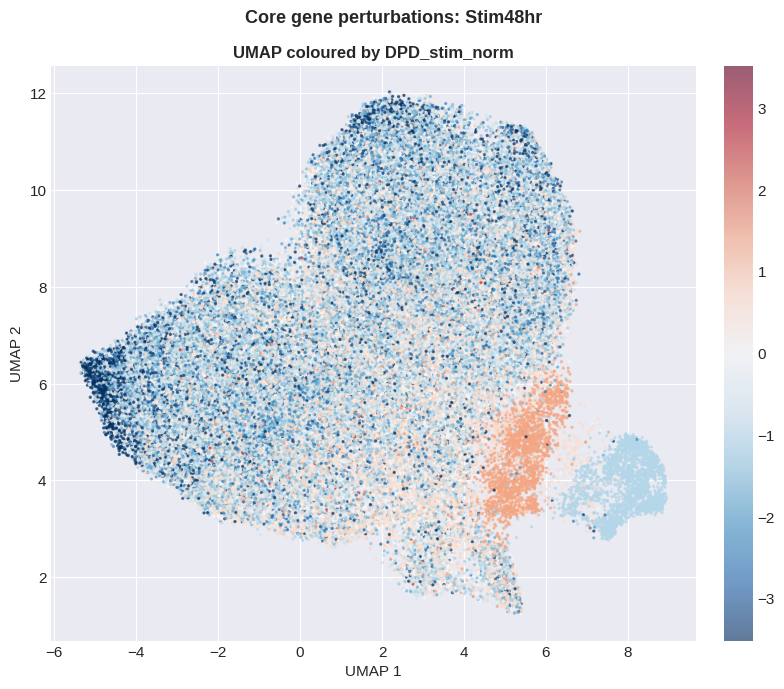

Saved: ../Results/Stim48hr/umap_core_perturbations_Stim48hr_D1_D2_D3_D4.png


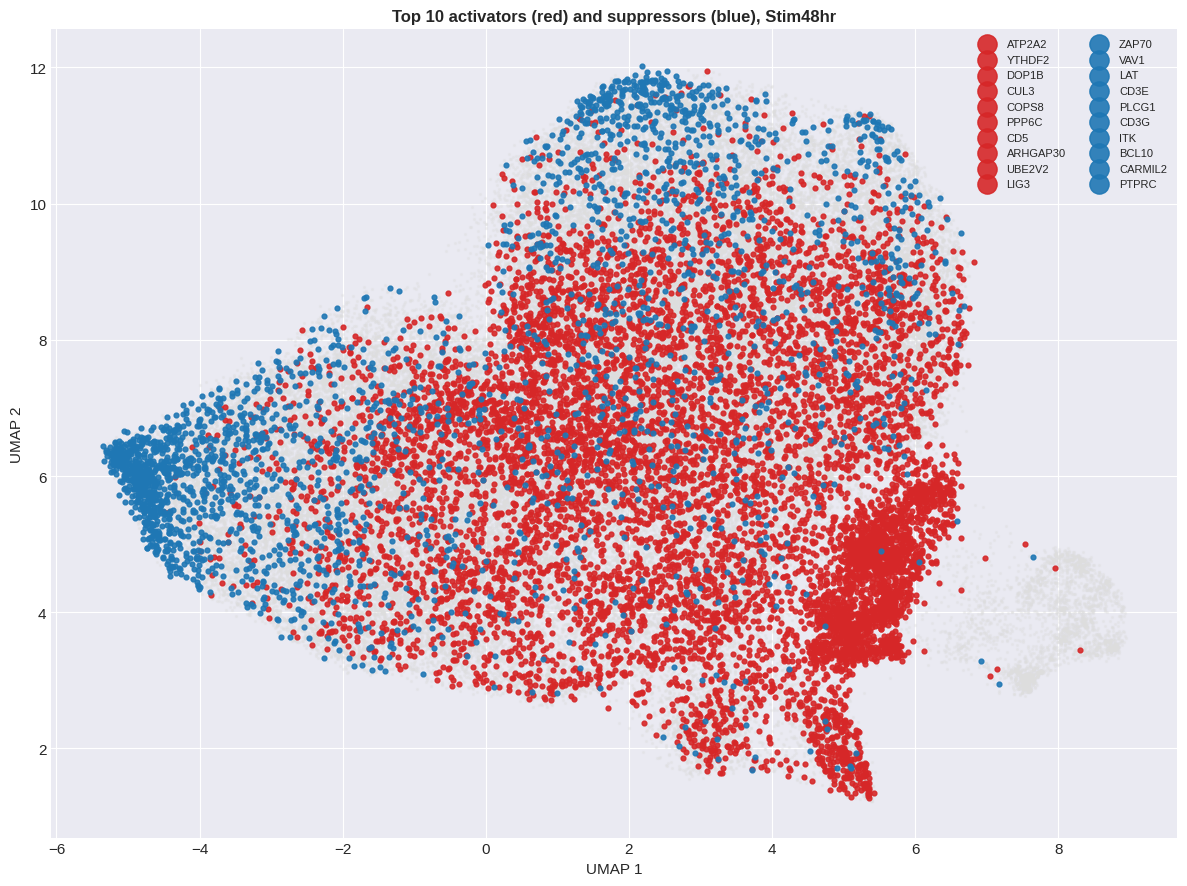

Saved: ../Results/Stim48hr/umap_top_perturbations_labelled_Stim48hr_D1_D2_D3_D4.png


In [9]:
UMAP_CACHE_PATH = os.path.join(OUT_DIR, f'umap_adata_{run_tag}.h5ad')

if not RUN_UMAP:
    print('RUN_UMAP=False, skipping.')
elif os.path.exists(UMAP_CACHE_PATH) and REPLOT_UMAP:
    print(f'Loading cached adata_umap from {UMAP_CACHE_PATH}')
    adata_umap = anndata.read_h5ad(UMAP_CACHE_PATH)
    print(f'Loaded: {adata_umap.shape}')
    plot_umap_panels(adata_umap, core_df)
    del adata_umap
    gc.collect()
else:
    print('Loading perturbed cells for core genes...')
    donor_adatas = []
    for donor in DONORS:
        fpath = os.path.join(DATA_DIR, f'{donor}_{CONDITION}.assigned_guide.h5ad')
        tmp = anndata.read_h5ad(fpath, backed='r')
        ntc_idx = np.where(tmp.obs['guide_type'] == 'non-targeting')[0]
        pert_idx = np.where(
            (tmp.obs['guide_type'] != 'non-targeting') &
            (tmp.obs['perturbed_gene_name'].isin(core_genes))
        )[0]
        n_ntc_sample = min(len(ntc_idx), 5000)  # cap NTC at 5,000 cells per donor
        rng = np.random.default_rng(42)
        ntc_sample = rng.choice(ntc_idx, size=n_ntc_sample, replace=False)
        keep_idx = np.concatenate([ntc_sample, pert_idx])
        sub = tmp[keep_idx].to_memory()
        tmp.file.close()
        donor_adatas.append(sub)
        print(f'  {donor}: {sub.n_obs:,} cells ({len(pert_idx):,} perturbed + {n_ntc_sample:,} NTC)')

    adata_umap = anndata.concat(donor_adatas, label='donor', keys=DONORS)
    del donor_adatas
    gc.collect()
    print(f'Combined: {adata_umap.shape}')

    sc.pp.normalize_total(adata_umap, target_sum=1e4)
    sc.pp.log1p(adata_umap)
    sc.pp.highly_variable_genes(adata_umap, n_top_genes=2000, flavor='seurat')
    sc.pp.pca(adata_umap, n_comps=50, mask_var='highly_variable')
    sc.pp.neighbors(adata_umap, n_neighbors=UMAP_N_NEIGHBORS, n_pcs=50)
    sc.tl.umap(adata_umap, min_dist=UMAP_MIN_DIST)
    print('UMAP computed.')
    adata_umap.write_h5ad(UMAP_CACHE_PATH)
    print(f'adata_umap cached to {UMAP_CACHE_PATH}')

    plot_umap_panels(adata_umap, core_df)
    del adata_umap
    gc.collect()

### 6. Save

Core gene table to `../Results/{CONDITION}`, `R` to `../Results/{CONDITION}/pseudobulk`.

In [10]:
# Core gene annotation table (node table for Notebooks 3+)
core_path = os.path.join(OUT_DIR, f'core_genes_{run_tag}.csv')
core_df.to_csv(core_path, index=False)
print(f'Saved: {core_path}')

# R (square, core x core) straight into the pseudobulk subfolder Notebook 3 reads from
R_path = os.path.join(PSEUDOBULK_OUT_DIR, f'R_{run_tag}.csv')
R_df.to_csv(R_path)
print(f'Saved: {R_path}')

print(f'\nDone, {run_tag}')
print(f'Core genes: {len(core_genes)}')
print(f'Outputs in: {OUT_DIR}')
print(f'R in: {PSEUDOBULK_OUT_DIR}')

Saved: ../Results/Stim48hr/core_genes_Stim48hr_D1_D2_D3_D4.csv
Saved: ../Results/Stim48hr/pseudobulk/R_Stim48hr_D1_D2_D3_D4.csv

Done, Stim48hr_D1_D2_D3_D4
Core genes: 200
Outputs in: ../Results/Stim48hr
R in: ../Results/Stim48hr/pseudobulk
